# Bayesian Network with pandas: Street-Food Chaat Stall 

A **Bayesian Network (BN)** has two parts:
1. A **DAG**: nodes are random variables, and arrows show direct influence.
2. A **CPT** for every node: `P(node | parents)`.

Multiplying the CPTs together gives the full joint distribution (the **chain rule**):

$$P(X_1, \dots, X_n) = \prod_i P(X_i \mid \text{Parents}(X_i))$$

### The story (synthetic dataset)
A chaat stall owner logs every evening of business:

| Variable | Values | Meaning |
|---|---|---|
| `Weather` | Sunny / Humid / Rainy | Evening weather |
| `Day_Type` | Weekday / Weekend / Festival | What kind of day it is |
| `Ingredient_Freshness` | Fresh / Stale | Do the chutneys and curd hold up in the weather? |
| `Footfall` | Low / Medium / High | How many people walk past the stall |
| `Queue_Length` | Short / Long | How long customers wait |
| `Sold_Out` | No / Yes | Did the stall run out of food before closing? |
| `Customer_Rating` | Poor / Good / Excellent | Average review that evening |

**How this notebook's code differs:** everything is done with **pandas tables**. CPTs are stored as long tables, learned with `value_counts`, the joint distribution is built with `merge`, and inference is a `groupby`.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

## 1. Network structure

In [20]:
STATES = {
    "Weather":              ["Sunny", "Humid", "Rainy"],
    "Day_Type":             ["Weekday", "Weekend", "Festival"],
    "Ingredient_Freshness": ["Fresh", "Stale"],
    "Footfall":             ["Low", "Medium", "High"],
    "Queue_Length":         ["Short", "Long"],
    "Sold_Out":             ["No", "Yes"],
    "Customer_Rating":      ["Poor", "Good", "Excellent"],
}

parents = {
    "Weather":              [],
    "Day_Type":             [],
    "Ingredient_Freshness": ["Weather"],
    "Footfall":             ["Weather", "Day_Type"],
    "Queue_Length":         ["Footfall"],
    "Sold_Out":             ["Footfall"],
    "Customer_Rating":      ["Ingredient_Freshness", "Queue_Length"],
}

ORDER = list(parents)  # topological order: parents come first

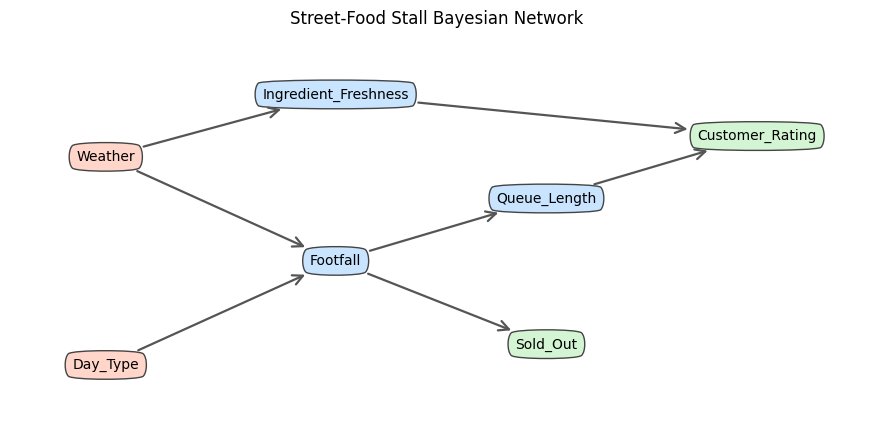

In [21]:
# Left-to-right drawing: causes on the left, outcomes on the right
pos = {
    "Weather": (0, 3), "Day_Type": (0, 1),
    "Ingredient_Freshness": (2.4, 3.6), "Footfall": (2.4, 2),
    "Queue_Length": (4.6, 2.6), "Sold_Out": (4.6, 1.2),
    "Customer_Rating": (6.8, 3.2),
}

def node_color(node):
    has_children = any(node in ps for ps in parents.values())
    if not parents[node]:
        return "#ffd6c9"   # root cause
    return "#c9e4ff" if has_children else "#d4f5d4"   # middle / final outcome

fig, ax = plt.subplots(figsize=(11, 5))
boxes = {}
for node, (x, y) in pos.items():
    boxes[node] = ax.text(x, y, node, ha="center", va="center", fontsize=10,
                          bbox=dict(boxstyle="round4,pad=0.6", fc=node_color(node), ec="#444"))
for child, pas in parents.items():
    for p in pas:   # patchA/patchB clip each arrow to the edges of the two boxes
        ax.annotate("", xy=pos[child], xytext=pos[p],
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.6, mutation_scale=18,
                                    patchA=boxes[p].get_bbox_patch(),
                                    patchB=boxes[child].get_bbox_patch()))
ax.set_xlim(-1, 7.9); ax.set_ylim(0.5, 4.2); ax.axis("off")
ax.set_title("Street-Food Stall Bayesian Network")
plt.savefig("street_food_dag.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Generate the dataset

The "true" CPTs below are written as **lists** in the same order as `STATES`. Instead of building one row at a time, we sample a **whole column at once**: for each combination of parent values, we fill in every matching row in a single call.

In [22]:
TRUE = {
    "Weather":  {(): [0.45, 0.30, 0.25]},
    "Day_Type": {(): [0.62, 0.28, 0.10]},
    "Ingredient_Freshness": {           # Weather -> Fresh, Stale
        ("Sunny",): [0.85, 0.15],
        ("Humid",): [0.60, 0.40],       # curd spoils in humidity
        ("Rainy",): [0.70, 0.30],
    },
    "Footfall": {                       # (Weather, Day_Type) -> Low, Medium, High
        ("Sunny", "Weekday"):  [0.30, 0.50, 0.20],
        ("Sunny", "Weekend"):  [0.10, 0.40, 0.50],
        ("Sunny", "Festival"): [0.05, 0.20, 0.75],
        ("Humid", "Weekday"):  [0.40, 0.45, 0.15],
        ("Humid", "Weekend"):  [0.20, 0.45, 0.35],
        ("Humid", "Festival"): [0.10, 0.30, 0.60],
        ("Rainy", "Weekday"):  [0.70, 0.25, 0.05],
        ("Rainy", "Weekend"):  [0.50, 0.35, 0.15],
        ("Rainy", "Festival"): [0.25, 0.40, 0.35],
    },
    "Queue_Length": {("Low",): [0.90, 0.10], ("Medium",): [0.55, 0.45], ("High",): [0.15, 0.85]},
    "Sold_Out":     {("Low",): [0.95, 0.05], ("Medium",): [0.75, 0.25], ("High",): [0.35, 0.65]},
    "Customer_Rating": {                # (Freshness, Queue) -> Poor, Good, Excellent
        ("Fresh", "Short"): [0.05, 0.45, 0.50],
        ("Fresh", "Long"):  [0.15, 0.50, 0.35],
        ("Stale", "Short"): [0.50, 0.40, 0.10],
        ("Stale", "Long"):  [0.70, 0.25, 0.05],
    },
}

In [23]:
def sample_column(data, node):
    """Sample one column for ALL rows, one parent combination at a time."""
    col = np.empty(len(data), dtype=object)
    for key, probs in TRUE[node].items():
        match = np.ones(len(data), dtype=bool)
        for p, v in zip(parents[node], key):
            match &= (data[p] == v).to_numpy()
        col[match] = rng.choice(STATES[node], size=match.sum(), p=probs)
    return col

data = pd.DataFrame(index=range(6000))
for node in ORDER:
    data[node] = sample_column(data, node)

data.to_csv("street_food_stall.csv", index=False)
data.head(10)

,Weather,Day_Type,Ingredient_Freshness,Footfall,Queue_Length,Sold_Out,Customer_Rating
0,Humid,Weekday,Stale,Medium,Long,No,Poor
1,Rainy,Weekday,Fresh,Medium,Long,No,Good
2,Rainy,Weekend,Stale,Low,Short,No,Good
3,Sunny,Weekday,Stale,Low,Short,Yes,Good
4,Sunny,Weekday,Fresh,Medium,Long,No,Good
5,Rainy,Weekday,Stale,Medium,Short,No,Poor
6,Sunny,Festival,Fresh,Low,Short,No,Good
7,Rainy,Weekday,Fresh,Medium,Long,No,Good
8,Rainy,Festival,Stale,Medium,Short,No,Good
9,Humid,Weekday,Fresh,Medium,Short,No,Good


In [24]:
data.describe()

,Weather,Day_Type,Ingredient_Freshness,Footfall,Queue_Length,Sold_Out,Customer_Rating
count,6000,6000,6000,6000,6000,6000,6000
unique,3,3,2,3,2,2,3
top,Sunny,Weekday,Fresh,Medium,Short,No,Good
freq,2773,3640,4432,2369,3314,4246,2654


## 3. Learn the CPTs from the data

Each CPT is stored as a **long table** with columns `[parents..., node, p]`:
1. `value_counts()` counts every observed combination.
2. `reindex` adds the combinations that never appeared, with count 0.
3. Adding `alpha = 1` (Laplace smoothing) means no probability is exactly 0.
4. Each count is divided by the total for its parent combination.

In [25]:
def learn_cpt(data, node, alpha=1):
    """Long-format CPT: one row per (parent values, node value) with its probability p."""
    cols = parents[node] + [node]
    full = pd.MultiIndex.from_product([STATES[c] for c in cols], names=cols)
    counts = data[cols].value_counts().reindex(full, fill_value=0) + alpha
    if parents[node]:
        probs = counts / counts.groupby(level=parents[node]).transform("sum")
    else:
        probs = counts / counts.sum()
    return probs.rename("p").reset_index()

cpts = {node: learn_cpt(data, node) for node in ORDER}
cpts["Queue_Length"]

,Footfall,Queue_Length,p
0,Low,Short,0.888454
1,Low,Long,0.111546
2,Medium,Short,0.536904
3,Medium,Long,0.463096
4,High,Short,0.143306
5,High,Long,0.856694


In [26]:
def as_wide(node):
    """Pivot a long CPT into the usual 'parents x states' table for reading."""
    t = cpts[node]
    if not parents[node]:
        return t.set_index(node).T
    return t.pivot_table(index=parents[node], columns=node, values="p")[STATES[node]]

for node in ORDER:
    print(f"P({node} | {', '.join(parents[node]) or '-'})")
    display(as_wide(node).round(3))

P(Weather | -)


Weather,Sunny,Humid,Rainy
p,0.462,0.288,0.25


P(Day_Type | -)


Day_Type,Weekday,Weekend,Festival
p,0.607,0.284,0.109


P(Ingredient_Freshness | Weather)


...

Queue_Length,Short,Long
Footfall,,
High,0.143,0.857
Low,0.888,0.112
Medium,0.537,0.463


P(Sold_Out | Footfall)


Sold_Out,No,Yes
Footfall,,
High,0.331,0.669
Low,0.951,0.049
Medium,0.750,0.250


P(Customer_Rating | Ingredient_Freshness, Queue_Length)


Customer_Rating                     Poor   Good  Excellent
Ingredient_Freshness Queue_Length                         
Fresh                Long          0.142  0.508      0.350
                     Short         0.055  0.461      0.484
Stale                Long          0.728  0.227      0.045
                     Short         0.503  0.407      0.090

## 4. Joint probability with merges

We start from a table holding **every possible evening** (3·3·2·3·2·2·3 = 648 rows). Then we `merge` in each CPT and multiply its `p` into a running column `P`. That is the chain rule applied to every row at once.

In [27]:
def build_joint(cpts):
    """Every full combination of values plus its probability (chain rule via merges)."""
    joint = pd.MultiIndex.from_product([STATES[n] for n in ORDER], names=ORDER).to_frame(index=False)
    joint["P"] = 1.0
    for node in ORDER:
        joint = joint.merge(cpts[node], on=parents[node] + [node])
        joint["P"] *= joint.pop("p")
    return joint

joint = build_joint(cpts)
print(len(joint), "rows, total probability =", round(joint.P.sum(), 4))
joint.sort_values("P", ascending=False).head()

648 rows, total probability = 1.0


,Weather,Day_Type,Ingredient_Freshness,Footfall,Queue_Length,Sold_Out,Customer_Rating,P
434,Rainy,Weekday,Fresh,Low,Short,No,Excellent,0.030369
2,Sunny,Weekday,Fresh,Low,Short,No,Excellent,0.029380
433,Rainy,Weekday,Fresh,Low,Short,No,Good,0.028947
1,Sunny,Weekday,Fresh,Low,Short,No,Good,0.028005
14,Sunny,Weekday,Fresh,Medium,Short,No,Excellent,0.022627


In [28]:
def prob(**values):
    """P(values): filter the joint table and add up P (works for full or partial assignments)."""
    rows = joint
    for k, v in values.items():
        rows = rows[rows[k] == v]
    return rows.P.sum()

print("P(perfect sunny festival evening) =",
      round(prob(Weather="Sunny", Day_Type="Festival", Ingredient_Freshness="Fresh",
                 Footfall="High", Queue_Length="Long", Sold_Out="Yes",
                 Customer_Rating="Excellent"), 4))
print("P(Rainy and Sold_Out)             =", round(prob(Weather="Rainy", Sold_Out="Yes"), 4))

P(perfect sunny festival evening) = 0.0066
P(Rainy and Sold_Out)             = 0.0442


## 5. Inference with filter + groupby

`P(target | evidence)`:
1. **Filter** the joint table down to the rows that match the evidence.
2. **Group** by the target and add up `P`.
3. **Normalize** so the result sums to 1.

Evidence is passed as keyword arguments, for example `query("Sold_Out", Weather="Rainy")`.

In [29]:
def query(target, **evidence):
    """Exact P(target | evidence) from the joint table."""
    rows = joint
    for k, v in evidence.items():
        rows = rows[rows[k] == v]
    dist = rows.groupby(target)["P"].sum()
    return (dist / dist.sum()).reindex(STATES[target]).round(3)

## 6. Asking the network questions

**Q1. On a random evening, how likely is the stall to sell out?**

In [30]:
query("Sold_Out")

Sold_Out
No     0.707
Yes    0.293
Name: P, dtype: float64

**Q2. How busy will it be on a rainy weekday compared with a sunny festival?**

In [31]:
pd.DataFrame({
    "Rainy weekday":  query("Footfall", Weather="Rainy", Day_Type="Weekday"),
    "Sunny festival": query("Footfall", Weather="Sunny", Day_Type="Festival"),
})

,Rainy weekday,Sunny festival
Footfall,,
Low,0.700,0.060
Medium,0.258,0.175
High,0.041,0.765


**Q3. The stall got a Poor rating. Were the ingredients stale?** (Reasoning from the effect back to the cause.)

In [32]:
pd.DataFrame({
    "Before any evidence": query("Ingredient_Freshness"),
    "Given rating = Poor": query("Ingredient_Freshness", Customer_Rating="Poor"),
})

,Before any evidence,Given rating = Poor
Ingredient_Freshness,,
Fresh,0.738,0.308
Stale,0.262,0.692


**Q4. Explaining away.** Footfall was High. Was it sunny?

- Seeing High footfall makes Sunny weather more likely.
- If we also learn it was a **Festival**, the festival already explains the crowd, so Sunny becomes less likely than before.

In [33]:
pd.DataFrame({
    "Prior":                    query("Weather"),
    "Footfall=High":            query("Weather", Footfall="High"),
    "Footfall=High + Festival": query("Weather", Footfall="High", Day_Type="Festival"),
})

,Prior,Footfall=High,Footfall=High + Festival
Weather,,,
Sunny,0.462,0.621,0.574
Humid,0.288,0.271,0.268
Rainy,0.250,0.108,0.158


**Q5. Chance of selling out in each kind of weather**

In [34]:
pd.DataFrame({w: query("Sold_Out", Weather=w) for w in STATES["Weather"]})

,Sunny,Humid,Rainy
Sold_Out,,,
No,0.644,0.708,0.823
Yes,0.356,0.292,0.177


## 7. Sanity checks

1. The network's answers should match plain frequencies in the data.
2. The learned CPTs should be close to the hidden `TRUE` ones. The biggest errors show up for **rare parent combinations** (e.g. a rainy festival evening), simply because there are few rows to count.

In [35]:
# 1. BN inference vs. raw frequency in the data
freq = data[data.Weather == "Rainy"].Customer_Rating.value_counts(normalize=True)
pd.DataFrame({
    "BN (learned)":   query("Customer_Rating", Weather="Rainy"),
    "Data frequency": freq.reindex(STATES["Customer_Rating"]).round(3),
})

,BN (learned),Data frequency
Customer_Rating,,
Poor,0.228,0.227
Good,0.439,0.451
Excellent,0.334,0.322


In [36]:
# 2. Put the TRUE CPTs in the same long format and merge them next to the learned ones
def true_long(node):
    rows = [(*key, s, p) for key, probs in TRUE[node].items()
            for s, p in zip(STATES[node], probs)]
    return pd.DataFrame(rows, columns=parents[node] + [node, "p_true"])

gaps = pd.concat([cpts[n].merge(true_long(n)).assign(node=n) for n in ORDER], ignore_index=True)
gaps["gap"] = (gaps.p - gaps.p_true).abs()
worst = gaps.loc[gaps.gap.idxmax()]
print(f"Largest |learned - true| over all CPT entries: {worst.gap:.3f}")
print(f"  at P({worst.node}={worst[worst.node]} | {dict(worst[parents[worst.node]])})")

Largest |learned - true| over all CPT entries: 0.072
  at P(Footfall=Medium | {'Weather': 'Rainy', 'Day_Type': 'Weekend'})


## Summary

- A 7-node Bayesian Network for a street-food stall, built entirely with **pandas tables**.
- **Learning:** `value_counts` + `reindex` + Laplace smoothing.
- **Joint distribution:** one table of all 648 evenings, built with `merge` (the chain rule).
- **Inference:** filter, then `groupby`, then normalize.
- The network covers predictive (Weather → Footfall), diagnostic (Rating → Freshness) and **explaining-away** (Festival vs Sunny) reasoning.